三角位置编码的实现

In [1]:
import torch
import torch.nn.functional as F
import numpy as np
import math
import torch.nn as nn
from  dataclasses import dataclass

In [4]:
@dataclass
class Args:
    max_seq_len:int
    dim:int


#三角位置编码核心实现
class PositionEncoding(nn.Module):
    def __init__(self, args):
        super().__init__()

        #位置编码的shape：[max_seq_len,dim]
        pe = torch.zeros(args.max_seq_len,args.dim)
        position = torch.arange(0,args.max_seq_len).unsqueeze(1)

        #计算频率  10000^(-2i/dim) -> exp(2i * (-log(10000)/dim))
        factor = torch.exp(torch.arange(0, args.dim, 2) * (-math.log(10000.0) / args.dim))

        #分别计算sin和cos
        pe[:, 0::2] = torch.sin(position * factor)
        pe[:, 1::2] = torch.cos(position * factor)

         # 增加一个batch size的维度，[batch, seq_len, dim]
        pe = pe.unsqueeze(0)

        # 注册到buffer，不计算梯度
        self.register_buffer("pe", pe)

    def forward(self, x):

        # 词向量 + 位置编码
        x = x + self.pe

        return x

In [5]:
args = Args(max_seq_len=512, dim=1024)
print(args)

position_encoder = PositionEncoding(args)
print(position_encoder.pe.shape)

Args(max_seq_len=512, dim=1024)
torch.Size([1, 512, 1024])


(512, 1024)


<Axes: >

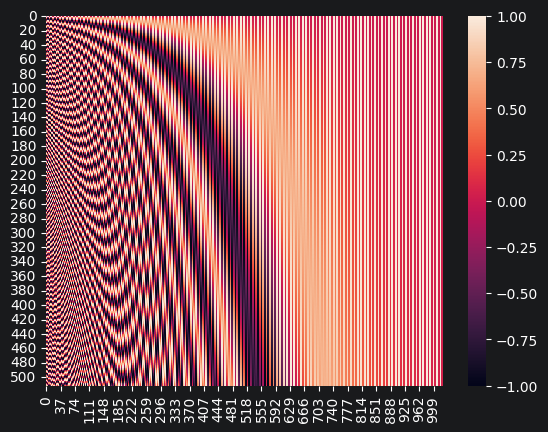

In [6]:
import seaborn as sns

# 热力图

print(position_encoder.pe[0].detach().numpy().shape)

sns.heatmap(position_encoder.pe[0].detach().numpy())